In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


# Read

In [4]:
#PC
root = "D:/Users/Admin/source_data/"

#Lap
root = "D:/Admin/source_data/"

In [5]:
price = pd.read_csv(root + "2017PurchasePricesDec.csv")
begInv = pd.read_csv(root + "BegInvFINAL12312016.csv")
endInv = pd.read_csv(root + "EndInvFINAL12312016.csv")
invoice = pd.read_csv(root + "InvoicePurchases12312016.csv")
purchase = pd.read_csv(root + "PurchasesFINAL12312016.csv")
sales = pd.read_csv(root + "SalesFINAL12312016.csv")

all_table = {
    "price": price,
    "begin": begInv,
    "end": endInv,
    "invoice": invoice,
    "purchase": purchase,
    "sales": sales
}

name_table = ["price", "begin", "end", "invoice", "purchase", "sales"]

In [6]:
for name in name_table:
    table = all_table[name]
    print(f"\nTable {name} include {table.shape[1]} columns:")
    print(table.columns.tolist())


Table price include 9 columns:
['Brand', 'Description', 'Price', 'Size', 'Volume', 'Classification', 'PurchasePrice', 'VendorNumber', 'VendorName']

Table begin include 9 columns:
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'startDate']

Table end include 9 columns:
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'endDate']

Table invoice include 10 columns:
['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate', 'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval']

Table purchase include 16 columns:
['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber', 'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification']

Table sales include 14 columns:
['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity', 'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification', 'ExciseTax', 

# Dữ liệu lỗi, tiền xử lý

## Missing, duplicate

In [8]:
# --- A. Chuyển đổi định dạng Ngày tháng (Date Conversion) ---
# Các bảng có cột ngày tháng cần được chuyển về datetime
date_columns = {
    'begin': ['startDate'],
    'end': ['endDate'],
    'invoice': ['InvoiceDate', 'PODate', 'PayDate'],
    'purchase': ['PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate'],
    'sales': ['SalesDate']
}

for table_name, cols in date_columns.items():
    for col in cols:
        all_table[table_name][col] = pd.to_datetime(all_table[table_name][col], errors='coerce')

In [9]:
# --- B. Xử lý giá trị thiếu (Missing Values) ---
def check_missing_values(data_dict):
    for name, df in data_dict.items():
        print(f"--- Missing values in {name} ---")
        print(df.isnull().sum()[df.isnull().sum() > 0])
        print("\n")

check_missing_values(all_table)

--- Missing values in price ---
Description    1
Size           1
Volume         1
dtype: int64


--- Missing values in begin ---
Series([], dtype: int64)


--- Missing values in end ---
City    1284
dtype: int64


--- Missing values in invoice ---
Series([], dtype: int64)


--- Missing values in purchase ---
Size    3
dtype: int64


--- Missing values in sales ---
Series([], dtype: int64)




In [10]:
print("--- Xử lý dữ liệu trùng lặp ---")
for name, df in all_table.items():
    print(f"Table {name:<10}: Đã xóa {df.duplicated().sum()} dòng trùng.")
    df.drop_duplicates(inplace=True)

--- Xử lý dữ liệu trùng lặp ---
Table price     : Đã xóa 0 dòng trùng.
Table begin     : Đã xóa 0 dòng trùng.
Table end       : Đã xóa 0 dòng trùng.
Table invoice   : Đã xóa 0 dòng trùng.
Table purchase  : Đã xóa 0 dòng trùng.
Table sales     : Đã xóa 0 dòng trùng.


In [11]:
# Định nghĩa các cột ngày tháng chính cho từng bảng để kiểm tra
target_date_cols = {
    "begin": "startDate",
    "end": "endDate",
    "invoice": "InvoiceDate",   # Ngày hóa đơn (Giao dịch tài chính)
    "purchase": "ReceivingDate", # Ngày nhận hàng thực tế (Giao dịch kho)
    "sales": "SalesDate"
}

print(f"{'Table':<10} | {'Column':<15} | {'Start Date':<12} | {'End Date':<12} | {'Duration (Days)'}")
print("-" * 75)

for name in name_table:
    df = all_table[name]
    
    # Bảng Price thường là bảng tham chiếu, không có cột ngày tháng giao dịch
    if name == "price":
        print(f"{name:<10} | {'N/A':<15} | {'Dữ liệu tham chiếu (Master Data)':<30}")
        continue

    # Lấy tên cột ngày tháng tương ứng
    col = target_date_cols.get(name)
    
    if col in df.columns:
        # Đảm bảo dữ liệu là datetime
        df[col] = pd.to_datetime(df[col], errors='coerce')
        
        min_date = df[col].min()
        max_date = df[col].max()
        
        if pd.notnull(min_date) and pd.notnull(max_date):
            duration = (max_date - min_date).days
            print(f"{name:<10} | {col:<15} | {min_date.strftime('%Y-%m-%d')} | {max_date.strftime('%Y-%m-%d')} | {duration}")
        else:
             print(f"{name:<10} | {col:<15} | {'Empty/Null'}")
    else:
        print(f"{name:<10} | {col:<15} | Not Found")

Table      | Column          | Start Date   | End Date     | Duration (Days)
---------------------------------------------------------------------------
price      | N/A             | Dữ liệu tham chiếu (Master Data)
begin      | startDate       | 2016-01-01 | 2016-01-01 | 0
end        | endDate         | 2016-12-31 | 2016-12-31 | 0
invoice    | InvoiceDate     | 2016-01-04 | 2017-01-10 | 372
purchase   | ReceivingDate   | 2016-01-01 | 2016-12-31 | 365
sales      | SalesDate       | 2016-01-01 | 2016-12-31 | 365


## Size

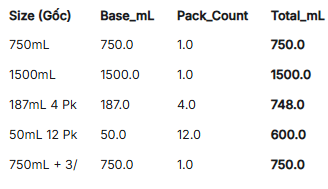

In [12]:
# format
price['Size_Clean'] = price['Size'].str.lower().str.strip()
price.loc[price['Size_Clean'] == 'unknown', 'Size_Clean'] = np.nan

# Base volume
price['Base_mL'] = price['Size_Clean'].str.extract(r'(\d+\.?\d*)\s*ml').astype(float)

# Pack Count
price['Pack_Count'] = price['Size_Clean'].str.extract(r'(\d+)\s*pk').astype(float)
price['Pack_Count'] = price['Pack_Count'].fillna(1)

# Special
mask_special = price['Size_Clean'].str.contains(r'750ml\s+3$', na=False)
price.loc[mask_special, 'Pack_Count'] = 1

# Total
price['Total_mL'] = price['Base_mL'] * price['Pack_Count']


* Update

In [13]:
volume_mapping = price[['Brand', 'Total_mL']].drop_duplicates(subset=['Brand']).set_index('Brand')['Total_mL'].to_dict()

target_tables = ['sales', 'purchase', 'begin', 'end']

for name in target_tables:
    df = all_table[name] 
    if 'Brand' in df.columns:
        df['Total_mL'] = df['Brand'].map(volume_mapping)
        missing_count = df['Total_mL'].isnull().sum()
        total_count = len(df)
        print(f"Table '{name}': Đã cập nhật. Missing: {missing_count}/{total_count} dòng ({(missing_count/total_count)*100:.2f}%)")

Table 'sales': Đã cập nhật. Missing: 0/12825363 dòng (0.00%)
Table 'purchase': Đã cập nhật. Missing: 0/2372474 dòng (0.00%)
Table 'begin': Đã cập nhật. Missing: 0/206529 dòng (0.00%)
Table 'end': Đã cập nhật. Missing: 0/224489 dòng (0.00%)


## Description- based Categorize wine

In [15]:
df = price.copy()
df['desc'] = df['Description'].str.lower().fillna('')

In [16]:
# MAIN CATEGORY
main_conditions = [
    # RTD phải bắt trước Spirits
    df['desc'].str.contains(r'rtd|ready to drink|margarita|long island|mudslide|cocktail'),

    # Spirits
    df['desc'].str.contains(r'vodka|whiskey|whisky|bourbon|scotch|rum|gin|tequila|brandy|cognac|moonshine'),

    # Liqueur
    df['desc'].str.contains(r'liqueur|schnapps|amaretto|cream|baileys|kahlua|jager|sambuca'),

    # Wine
    df['desc'].str.contains(r'wine|cab|merlot|chard|pinot|riesling|svgn|moscato|prosecco|champagne'),

    # Beer / Cider
    df['desc'].str.contains(r'beer|ale|lager|stout|cider'),

    # Sake
    df['desc'].str.contains(r'sake|soju')
]

main_choices = [
    'RTD',
    'Spirits',
    'Liqueur',
    'Wine',
    'Beer/Cider',
    'Sake'
]

df['alcohol_main'] = np.select(main_conditions, main_choices, default='Other')

In [17]:
mask_spirits = df['alcohol_main'] == 'Spirits'
d_spirits = df.loc[mask_spirits, 'desc']

df.loc[mask_spirits, 'alcohol_type'] = np.select(
    [
        d_spirits.str.contains(r'vodka'),
        d_spirits.str.contains(r'tequila|mezcal|agave'),
        d_spirits.str.contains(r'bourbon'),
        d_spirits.str.contains(r'tennessee|jack daniel'),
        d_spirits.str.contains(r'scotch'),
        d_spirits.str.contains(r'rye'),
        d_spirits.str.contains(r'irish'),
        d_spirits.str.contains(r'canadian'),
        d_spirits.str.contains(r'rum'),
        d_spirits.str.contains(r'gin'),
        d_spirits.str.contains(r'brandy|cognac|armagnac'),
        d_spirits.str.contains(r'moonshine'),
        d_spirits.str.contains(r'schnapps')
    ],
    [
        'Vodka',
        'Tequila',
        'Whiskey - Bourbon',
        'Whiskey - Tennessee',
        'Whiskey - Scotch',
        'Whiskey - Rye',
        'Whiskey - Irish',
        'Whiskey - Canadian',
        'Rum',
        'Gin',
        'Brandy/Cognac',
        'Moonshine',
        'Schnapps'
    ],
    # Default cũng phải tính trên tập d_spirits
    default=np.where(d_spirits.str.contains(r'whisky|whiskey'), 
                     'Whiskey - General', 
                     'Other Spirits')
)

# 2. Xử lý WINE
mask_wine = df['alcohol_main'] == 'Wine'
d_wine = df.loc[mask_wine, 'desc']

df.loc[mask_wine, 'alcohol_type'] = np.select(
    [
        d_wine.str.contains(r'champagne|sparkling|brut|prosecco|spumante|cava'),
        d_wine.str.contains(r'cabernet|cab svgn|cab\b'),
        d_wine.str.contains(r'merlot'),
        d_wine.str.contains(r'pinot noir|pnt nr'),
        d_wine.str.contains(r'malbec'),
        d_wine.str.contains(r'shiraz|syrah'),
        d_wine.str.contains(r'zinfandel|znfdl'),
        d_wine.str.contains(r'red blend|red table|rouge'),
        
        d_wine.str.contains(r'chardonnay|chard'),
        d_wine.str.contains(r'sauvignon blanc|svgn bl'),
        d_wine.str.contains(r'riesling|rsl'),
        d_wine.str.contains(r'pinot grigio|pnt gr|pinot gris'),
        d_wine.str.contains(r'moscato|muscat'),
        d_wine.str.contains(r'white blend|white table|blanc'),
        
        d_wine.str.contains(r'rose|rosé|blush|pink|white zinfandel'),
        d_wine.str.contains(r'port|sherry|vermouth|marsala|madeira')
    ],
    [
        'Sparkling',
        'Red - Cabernet',
        'Red - Merlot',
        'Red - Pinot Noir',
        'Red - Malbec',
        'Red - Shiraz/Syrah',
        'Red - Zinfandel',
        'Red - Blend/Other',
        
        'White - Chardonnay',
        'White - Sauvignon Blanc',
        'White - Riesling',
        'White - Pinot Grigio',
        'Sweet - Moscato',
        'White - Blend/Other',
        
        'Rose/Blush',
        'Fortified (Port/Sherry)'
    ],
    default='Other Wine'
)

# 3. Xử lý LIQUEUR
mask_liqueur = df['alcohol_main'] == 'Liqueur'
d_liqueur = df.loc[mask_liqueur, 'desc']

df.loc[mask_liqueur, 'alcohol_type'] = np.select(
    [
        d_liqueur.str.contains(r'cream|baileys|rumchata'),
        d_liqueur.str.contains(r'coffee|kahlua'),
        d_liqueur.str.contains(r'triple sec|curacao|grand marnier|cointreau'),
        d_liqueur.str.contains(r'amaretto'),
        d_liqueur.str.contains(r'peppermint|mint')
    ],
    [
        'Cream Liqueur',
        'Coffee Liqueur',
        'Citrus/Orange Liqueur',
        'Nut Liqueur',
        'Mint Liqueur'
    ],
    default='Fruit/Herbal Liqueur'
)

In [18]:
# STYLE / FLAVOR

flavor_check_mask = df['alcohol_main'].isin(['Spirits', 'RTD', 'Liqueur', 'Beer/Cider'])

# Các điều kiện
cond_flavor = (flavor_check_mask) & (df['desc'].str.contains(r'flavor|vanilla|apple|honey|peach|cherry|raspberry|coconut|pineapple|lime|lemon|orange|berry|melon'))
cond_single_malt = df['desc'].str.contains(r'single malt')
cond_spiced = df['desc'].str.contains(r'spiced')
cond_cream = df['desc'].str.contains(r'cream') 
cond_aged = df['desc'].str.contains(r'aged|reserve|barrel|xo|vsop|anejo|reposado|12 yr|15 yr|18 yr')

df['alcohol_style'] = np.select(
    [cond_single_malt, cond_spiced, cond_flavor, cond_aged],
    ['Single Malt', 'Spiced', 'Flavored', 'Aged/Premium'],
    default='Standard'
)

In [20]:
df["alcohol_main"].value_counts()

Other         7214
Wine          2855
Spirits       1629
Liqueur        296
Beer/Cider     142
RTD             80
Sake            45
Name: alcohol_main, dtype: int64

In [21]:
df["alcohol_type"].value_counts()

Red - Cabernet             950
White - Chardonnay         811
Vodka                      499
Red - Merlot               323
Rum                        308
White - Sauvignon Blanc    291
Tequila                    180
Fruit/Herbal Liqueur       162
Sweet - Moscato            155
Gin                        155
Sparkling                  115
Brandy/Cognac              114
Whiskey - Bourbon          108
Whiskey - General          107
Other Wine                  88
Whiskey - Scotch            86
Cream Liqueur               67
White - Pinot Grigio        43
Red - Pinot Noir            39
Whiskey - Irish             36
Nut Liqueur                 29
Coffee Liqueur              22
White - Riesling            20
Moonshine                   16
Whiskey - Canadian          10
Whiskey - Rye                9
Mint Liqueur                 9
Citrus/Orange Liqueur        7
Red - Zinfandel              4
Rose/Blush                   4
Red - Malbec                 3
Red - Blend/Other            3
White - 

In [22]:
df["alcohol_style"].value_counts()

Standard        11485
Aged/Premium      328
Flavored          327
Spiced             66
Single Malt        55
Name: alcohol_style, dtype: int64

# Phân phối dữ liệu

## Histogram

Text(0.5, 1.0, 'Phân phối số lượng hàng tồn kho (onHand)')

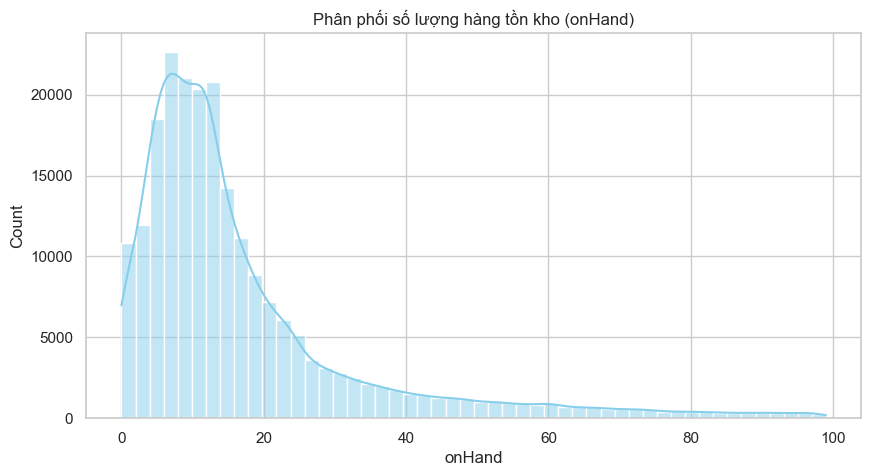

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(endInv[endInv['onHand']<100]['onHand'], bins=50, kde=True, color='skyblue') 
plt.title('Phân phối số lượng hàng tồn kho (onHand)')

Text(0.5, 1.0, 'Phân phối Giá nhập (PurchasePrice)')

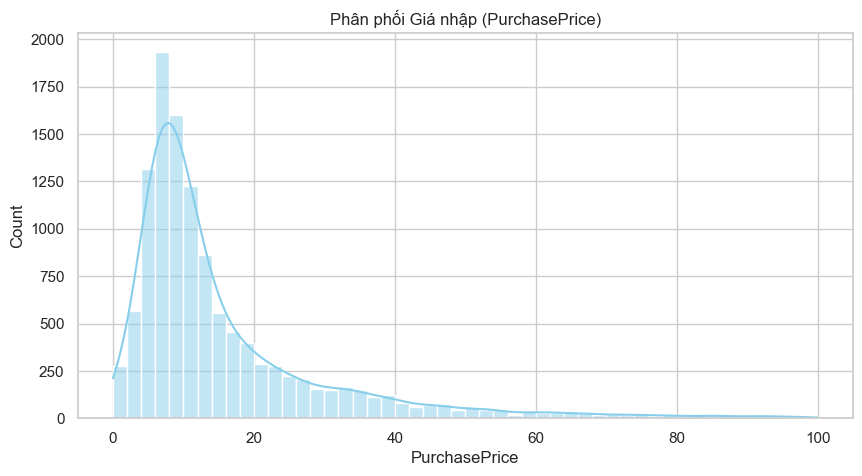

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(price[price['PurchasePrice']<100]['PurchasePrice'], bins=50, kde=True, color='skyblue') 
plt.title('Phân phối Giá nhập (PurchasePrice)')

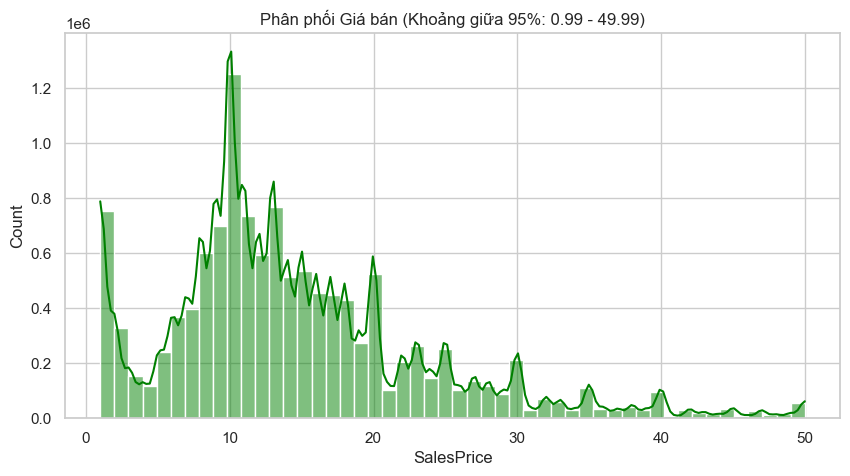

In [25]:
lower = sales['SalesPrice'].quantile(0.025) # Ngưỡng dưới 2.5%
upper = sales['SalesPrice'].quantile(0.975) # Ngưỡng trên 97.5%

# Lọc dữ liệu nằm trong khoảng giữa
data_95_middle = sales[(sales['SalesPrice'] >= lower) & (sales['SalesPrice'] <= upper)]['SalesPrice']

plt.figure(figsize=(10,5))
sns.histplot(data_95_middle, bins=50, kde=True, color='green')
plt.title(f'Phân phối Giá bán (Khoảng giữa 95%: {lower:.2f} - {upper:.2f})')
plt.show()

## Pareto

In [31]:
sales['VendorName'].nunique()

130

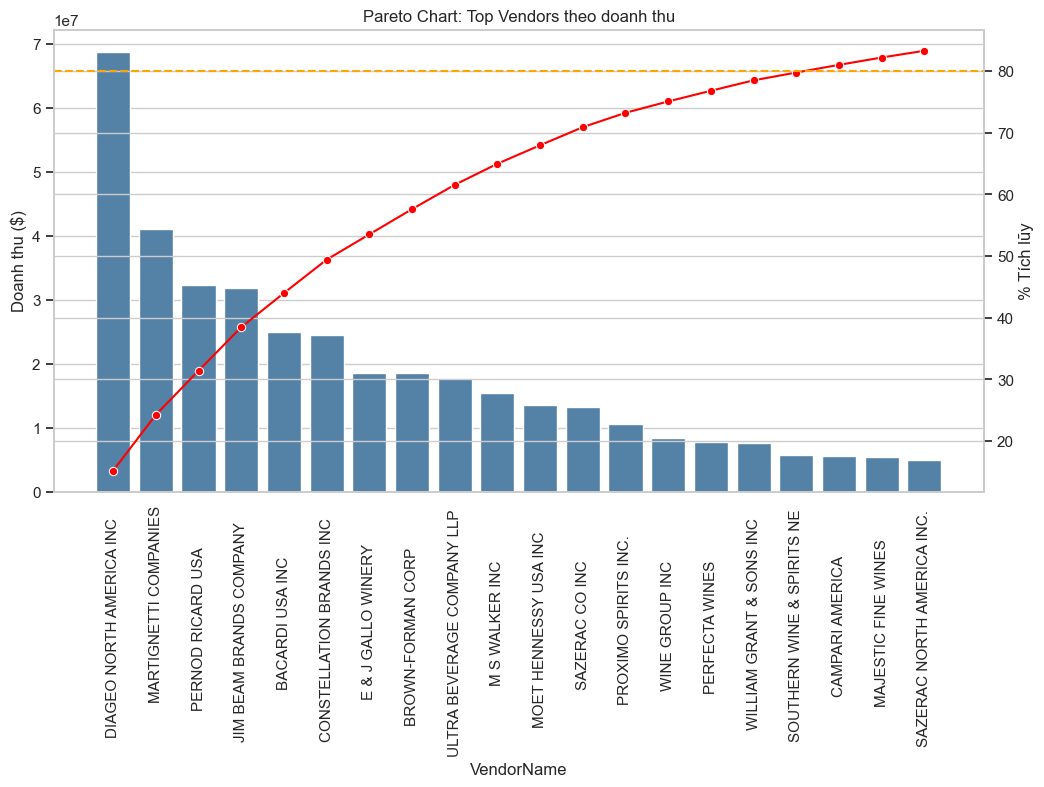

In [27]:
# Tính tổng doanh thu theo Vendor
top_vendors = sales.groupby('VendorName')['SalesDollars'].sum().sort_values(ascending=False).reset_index()

# Tính % tích lũy
top_vendors['cumulative_sum'] = top_vendors['SalesDollars'].cumsum()
top_vendors['cumulative_perc'] = 100 * top_vendors['cumulative_sum'] / top_vendors['SalesDollars'].sum()

# Lấy Top 20 Vendor để vẽ cho gọn
top_20_vendors = top_vendors.head(20)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart: Doanh thu
sns.barplot(data=top_20_vendors, x='VendorName', y='SalesDollars', color='steelblue', ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
ax1.set_ylabel('Doanh thu ($)')

# Line chart: % Tích lũy
ax2 = ax1.twinx()
sns.lineplot(data=top_20_vendors, x='VendorName', y='cumulative_perc', color='red', marker='o', ax=ax2)
ax2.set_ylabel('% Tích lũy')
ax2.axhline(80, color='orange', linestyle='--') # Đường 80%

plt.title('Pareto Chart: Top Vendors theo doanh thu')
plt.show()

`Phân tích: Nếu đường màu đỏ chạm mốc 80% chỉ với một số ít Vendor (bên trái), điều này chứng tỏ cửa hàng phụ thuộc lớn vào các nhà cung cấp này.`


## Distribution

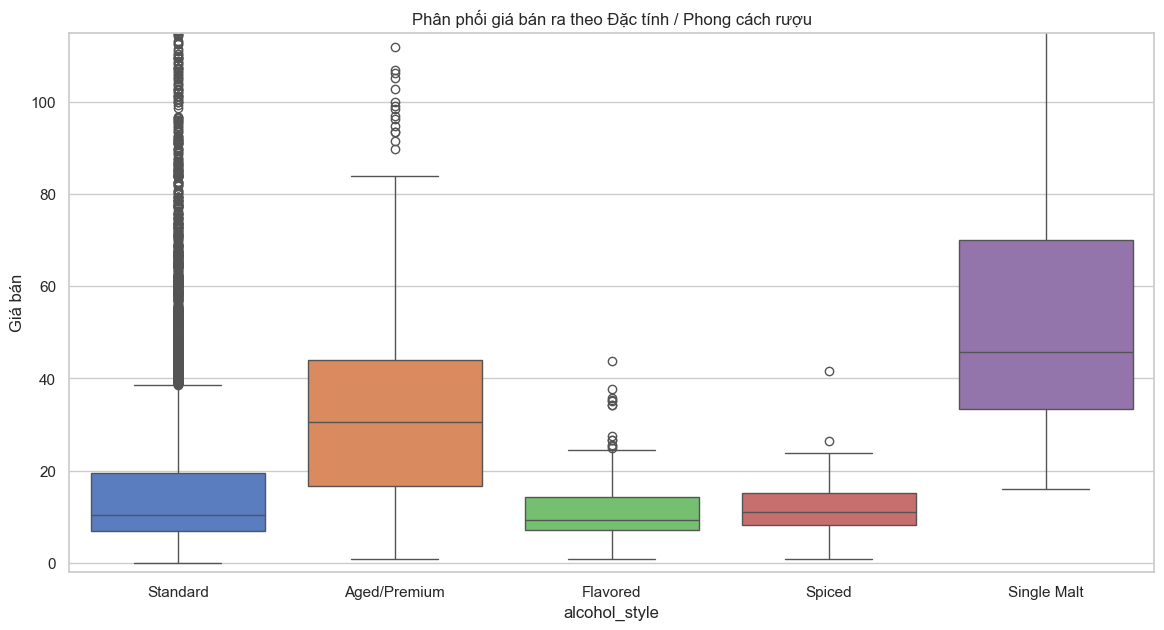

In [192]:
plt.figure(figsize=(14, 7))

# Vẽ Violin plot cho Số lượng bán ra của Top 5 Brand
sns.boxplot(x='alcohol_style', y='PurchasePrice', data=df, palette="muted")

plt.title('Phân phối giá bán ra theo Đặc tính / Phong cách rượu')
plt.xlabel('alcohol_style')
plt.ylabel('Giá bán')
# plt.xticks(rotation=45)
plt.ylim([-2,115])
plt.show()

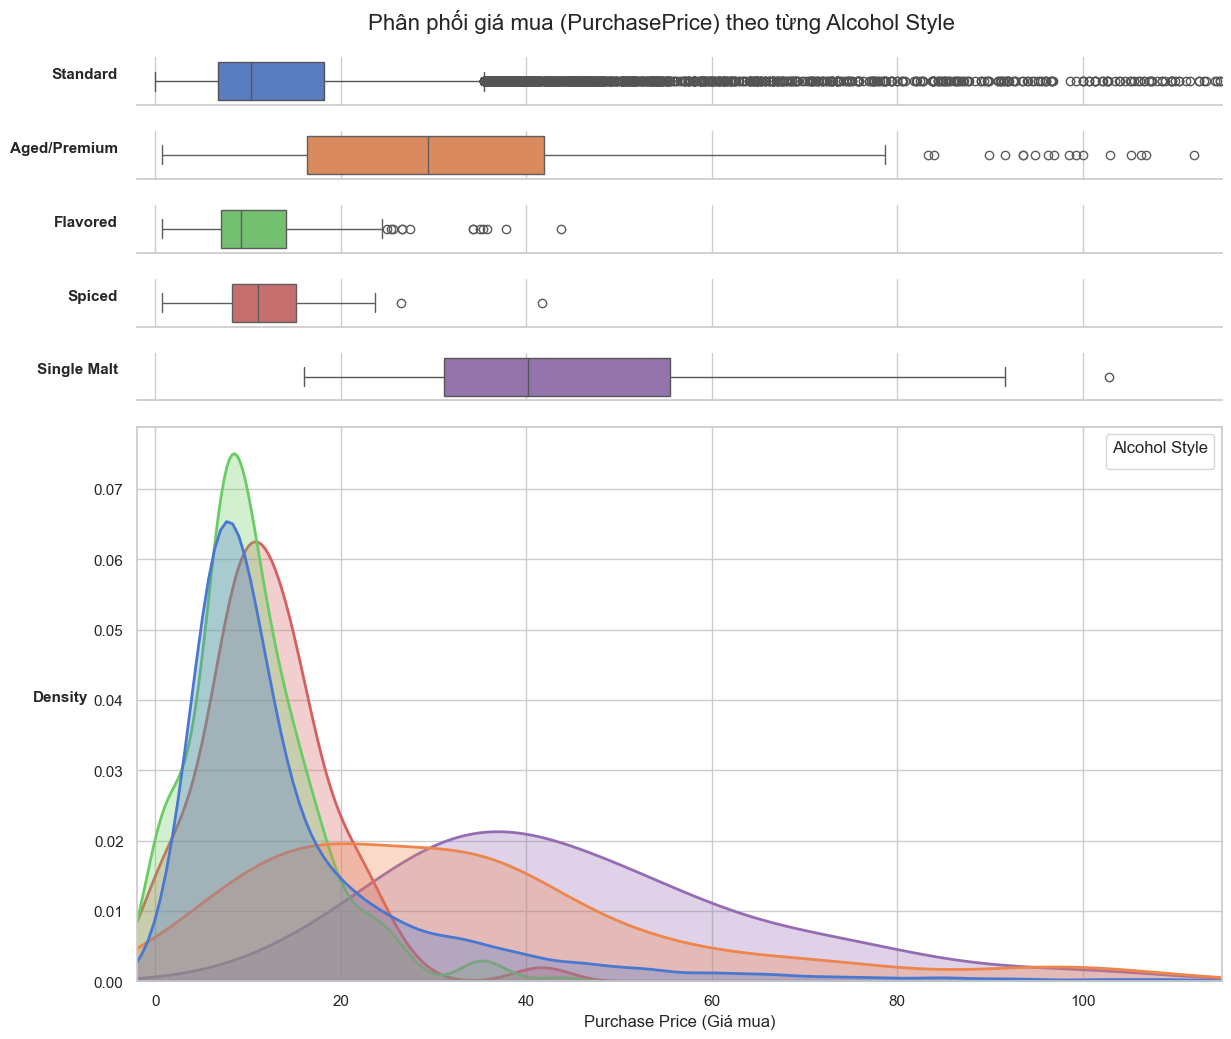

In [210]:
styles = df['alcohol_style'].dropna().unique()
df = df[df["PurchasePrice"]<=115]
if len(styles) > 5:
    styles = styles[:5]

palette = sns.color_palette("muted", n_colors=len(styles))
style_color_map = dict(zip(styles, palette))

# 3. Tạo subplots: 6 hàng, 1 cột
# sharex=True để tất cả dùng chung trục X (Giá)
fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(14, 12), sharex=True, height_ratios=(.06, .06, .06, .06, .06, .7))

# 4. Vẽ 5 Boxplot nằm ngang cho từng loại
for i, style in enumerate(styles):
    # Lọc dữ liệu của style đó
    subset = df[df['alcohol_style'] == style]
    
    # Vẽ boxplot nằm ngang (gán biến vào trục x)
    sns.boxplot(x='PurchasePrice', data=subset, ax=axs[i], color=style_color_map[style])
    
    # Trang trí: Đặt tên trục Y là tên style để dễ nhìn
    axs[i].set_ylabel(style, rotation=0, ha='right', fontsize=11, fontweight='bold')
    axs[i].set_xlabel('') # Bỏ nhãn trục X cho các biểu đồ con ở trên cho đỡ rối
    
    # Tùy chọn: bỏ bớt viền cho thoáng mắt
    sns.despine(ax=axs[i], left=True)

# 5. Vẽ KDE Plot tổng hợp ở hàng cuối cùng (axs[5])
sns.kdeplot(
    data=df[df['alcohol_style'].isin(styles)], 
    x='PurchasePrice', 
    hue='alcohol_style', 
    palette=style_color_map, 
    fill=True, 
    ax=axs[5],
    alpha=0.3,
    common_norm=False,
    linewidth=2
)

axs[5].set_ylabel('Density', rotation=0, ha='right', fontsize=11, fontweight='bold')
axs[5].set_xlabel('Purchase Price (Giá mua)', fontsize=12)
axs[5].legend(loc='upper right', title='Alcohol Style')

# 6. Thiết lập giới hạn trục X chung (như yêu cầu của bạn)
plt.xlim([-2, 115])

# Tiêu đề chung
plt.suptitle('Phân phối giá mua (PurchasePrice) theo từng Alcohol Style', y=0.92, fontsize=16)

# Tự động căn chỉnh khoảng cách
plt.subplots_adjust(hspace=0.2) # hspace chỉnh khoảng cách giữa các hàng
plt.show()

# Thống kê đặc trưng

In [120]:
pd.DataFrame(price["Price"].describe()).T

,count,mean,std,min,25%,50%,75%,max
Price,12261.0,38.64024,206.151172,0.0,10.99,15.99,29.99,13999.9


In [121]:
pd.DataFrame(price["Total_mL"].describe()).T

,count,mean,std,min,25%,50%,75%,max
Total_mL,12256.0,847.87243,679.776576,50.0,750.0,750.0,750.0,20000.0


In [122]:
pd.DataFrame(endInv["onHand"].describe()).T

,count,mean,std,min,25%,50%,75%,max
onHand,224489.0,21.763988,37.233576,0.0,7.0,12.0,22.0,3676.0


# Scatter

In [213]:
price[price["Description"] == "Jim Beam w/2 Rocks Glasses"]

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
8753,1004,Jim Beam w/2 Rocks Glasses,16.49,750mL,750,1,10.65,12546,JIM BEAM BRANDS COMPANY


In [211]:
sales.head()

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName,Total_mL
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2016-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY,750.0
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2016-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY,750.0
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2016-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY,750.0
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2016-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY,750.0
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2016-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY,750.0


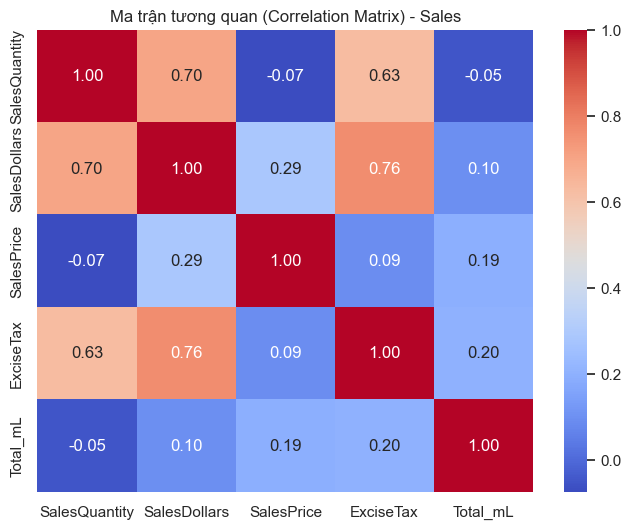

In [129]:
# --- Correlation Matrix (Heatmap) ---
# Chọn các cột số quan trọng trong bảng Sales
cols_corr = ['SalesQuantity', 'SalesDollars', 'SalesPrice', 'ExciseTax', 'Total_mL']
corr_matrix = sales[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan (Correlation Matrix) - Sales')
plt.show()



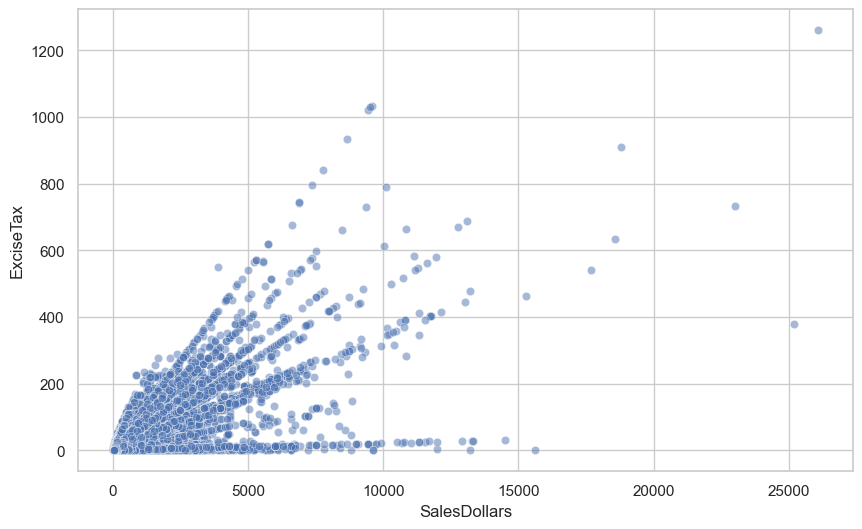

In [131]:
# --- Scatter Plot ---

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sales, x='SalesDollars', y='ExciseTax', alpha=0.5)
plt.xlabel('SalesDollars')
plt.ylabel('ExciseTax')
plt.show()

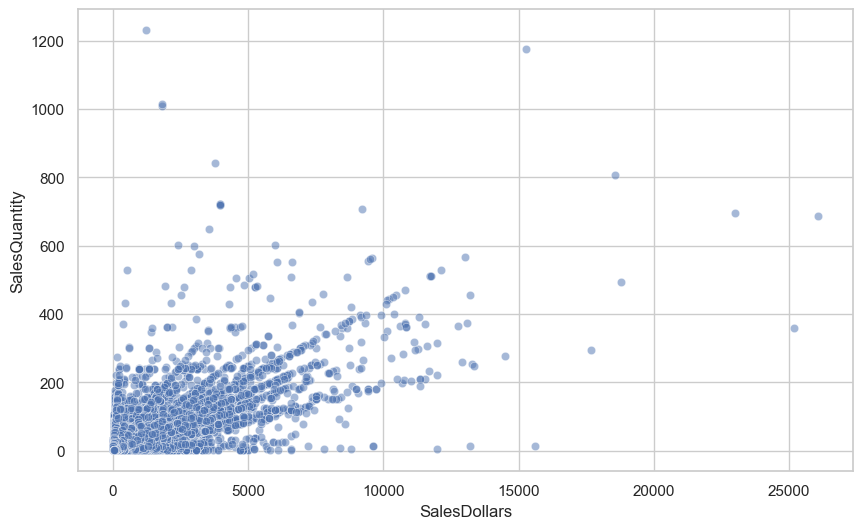

In [134]:
# --- Scatter Plot ---

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sales, x='SalesDollars', y='SalesQuantity', alpha=0.5)
plt.xlabel('SalesDollars')
plt.ylabel('SalesQuantity')
plt.show()

# Seasonal

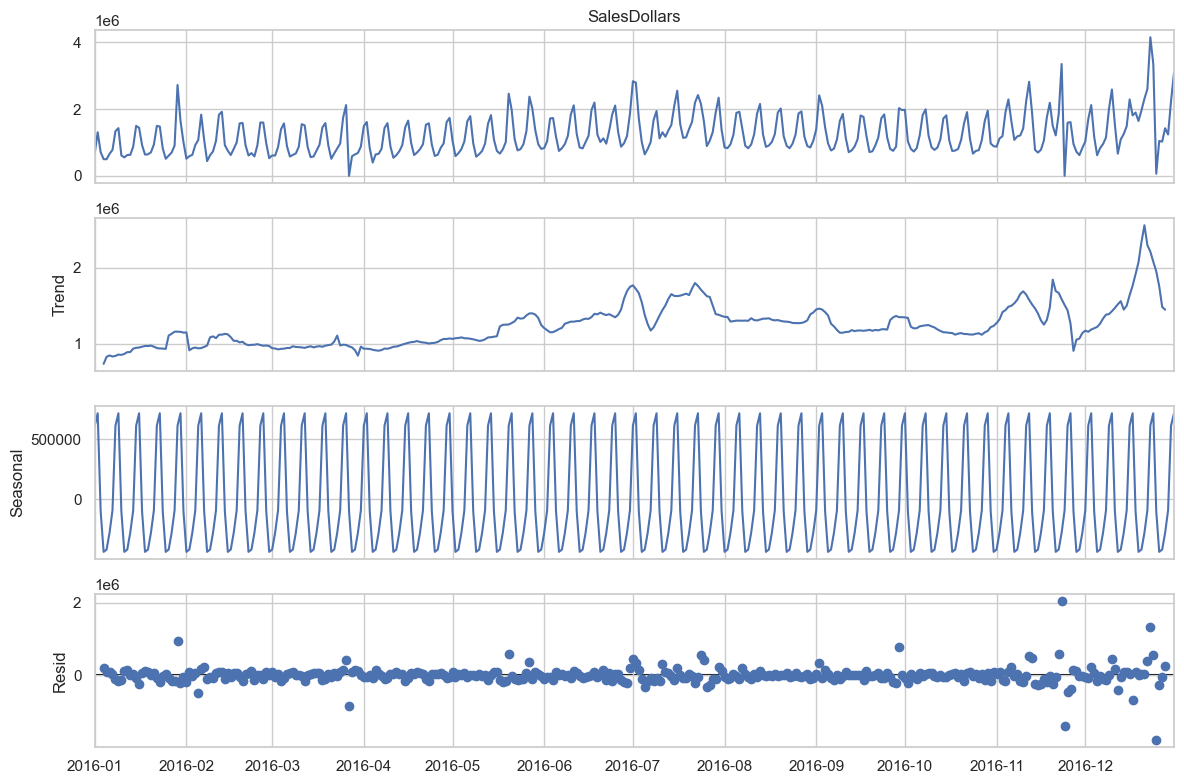

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu: Group theo ngày -> Set tần suất là Ngày ('D') -> Điền 0 vào ngày không bán
ts_data = sales.groupby('SalesDate')['SalesDollars'].sum().asfreq('D').fillna(0)

# 2. Thực hiện Decomposition
# period=7: Tìm quy luật lặp lại mỗi 7 ngày (Thứ 2 - CN)
# model='additive': Dùng mô hình cộng (Doanh thu = Trend + Season + Resid)
result = seasonal_decompose(ts_data, model='additive', period=7)

# 3. Vẽ biểu đồ
plt.rcParams.update({'figure.figsize': (12, 8)})
result.plot()
plt.show()